## Tools in Langgraph


First import all the necessary libraries


In [14]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests

load_dotenv()
import os

Define the required tools

1. DuckDuckGo search tool.
2. Basic Calculator Tool.
3. Stock Price Fetcher Tool.

In [39]:
#Tools
search_tool = DuckDuckGoSearchRun(region='us-en')

#Simple Calculator Tool
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """ 
    Perform a basic arithmetic operation on 2 numbers.
    Supported operations: add, sub, mul and div
    """

    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == 'div':
            if second_num == 0:
                return {'error': 'Division by zero is not allowed'}
            result = first_num / second_num
        else:
            return {"error" : {"Unsupported operation '{operation}'"}}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation,"result": result}
    except Exception as e:
        return {'error': str(e)}
    
#Tools for getting the stock price
@tool 
def get_stock_price(symbol:str) -> dict:
    """ 
    Fetch the latest stock price for a given symbol ( e.g. 'AAPL', 'TSLA')
    using Alpha Vantage with API key in the URL.
    """

    stock_api = os.getenv('ALPHA_VANTAGE_STOCK_API')
    
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={stock_api}"
    r = requests.get(url)
    return r.json()

Now lets a  tool list and give them to the llm

In [40]:
tools = [get_stock_price, search_tool, calculator]

llm = ChatOpenAI()
llm_with_tools = llm.bind_tools(tools)

Now lets create our graph

First define the state with all the variable required.

In [41]:
class ChatState(TypedDict):

    #Here this is a reducer which says this datapoint gets added everytime and not replaced while running the node
    messages: Annotated[list[BaseMessage], add_messages]

    

Lets define the functions for the nodes.

We need define the tools as a toolnode. 

In [42]:
def chat_node(state: ChatState):
    """ 
    LLM node that may ansswer or request a tool call.
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

Now lets make the graph

In [43]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ChatState)

#Lets add the nodes
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

#Now lets add the edges
graph.add_edge(START, "chat_node")

#IF the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)


Now, lets compile the graph

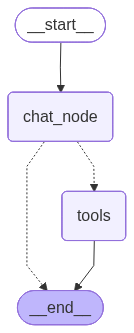

In [44]:
workflow = graph.compile()

workflow

Now, lets test it:

1. Regular Chat

In [45]:
# Regular chat

out = workflow.invoke({'messages': [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)

Hello! How can I assist you today?


2. Chat requiring calculator tool calling

In [34]:
out = workflow.invoke({"messages": [HumanMessage(content="What is 2x3")]})

print(out['messages'][-1].content)

{"first_num": 2.0, "second_num": 3.0, "operation": "mul", "result": 6.0}


3. Chat requiring stock price tool calling

In [ ]:
out = workflow.invoke({"messages": [HumanMessage(content="What is the stock price of Microsoft?")]})

print(out['messages'][-1].content)

{"Global Quote": {"01. symbol": "MSFT", "02. open": "432.5450", "03. high": "450.3300", "04. low": "432.3600", "05. price": "450.2400", "06. volume": "79654376", "07. latest trading day": "2026-05-29", "08. previous close": "426.9900", "09. change": "23.2500", "10. change percent": "5.4451%"}}


4. Lets make a little bit more complex rather than just returning the tool value to the output directly

In [47]:
out = workflow.invoke({"messages": [HumanMessage(content="What is the stock price of Microsoft?, How much would it cost to buy 10 shares of microsoft?")]})

print(out['messages'][-1].content)

{"first_num": 10.0, "second_num": 0.0, "operation": "mul", "result": 0.0}


### Now, there is problem in this design, where after calling the tool, the conteol is not going back the LLM for it to be doing something with the output, like again calling a different tool etc. So, the graph connection between the tool and the LLM should be back and forth and not one way.

### Now to put this loop, its simple, we just create an edge between tools and the LLM starting from the tools etc.

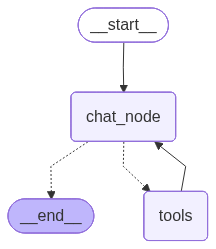

In [48]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ChatState)

#Lets add the nodes
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

#Now lets add the edges
graph.add_edge(START, "chat_node")

#IF the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

#ADDITIONAL EDGE BETWEEN THE TOOL AND THE LLM
graph.add_edge("tools","chat_node")

#Now compile it again
workflow = graph.compile()

workflow

Now lets test this one.

In [49]:
out = workflow.invoke({"messages": [HumanMessage(content="What is 2x3")]})

print(out['messages'][-1].content)

The result of 2 multiplied by 3 is 6.


Here, we see that, now we are getting a refined output, not the direct tool json output

In [50]:
out = workflow.invoke({"messages": [HumanMessage(content="What is the stock price of Microsoft?")]})

print(out['messages'][-1].content)

The current stock price of Microsoft (MSFT) is $450.24.


Now, lets see the usage of multiple tool calling

In [51]:
out = workflow.invoke({"messages": [HumanMessage(content="What is the stock price of Microsoft?, How much would it cost to buy 10 shares of microsoft?")]})

print(out['messages'][-1].content)

The current stock price of Microsoft (MSFT) is $450.24. 
To buy 10 shares of Microsoft, it would cost $4502.40.
